# MedSum-AI: Data Cleansing Pipeline
## Notebook 02 — Data Quality Enhancement

**Following Rahm & Do (2000) taxonomy for data cleaning**

Pipeline Steps:
1. Load raw parsed data
2. Handle missing values (listwise deletion for critical fields)
3. Remove duplicate reports (TF-IDF cosine similarity > 0.95)
4. Filter malformed/truncated entries (<20 tokens)
5. Text normalization & medical abbreviation standardization
6. XXXX placeholder handling
7. Final cleaned dataset statistics


In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded!")


Libraries loaded!


## Step 1: Load Raw Data

In [2]:
# Load the parsed data from EDA notebook
df = pd.read_csv('../data/iu_cxr_reports_parsed.csv')
initial_count = len(df)
print(f"Initial dataset size: {initial_count} records")
print(f"Columns: {list(df.columns)}")

# Track cleaning steps
cleaning_log = []
cleaning_log.append(('Raw Input', initial_count, 0, '-'))


Initial dataset size: 3955 records
Columns: ['uid', 'pmc_id', 'filename', 'findings', 'impression', 'indication', 'comparison', 'mesh_major', 'mesh_minor', 'num_images', 'image_ids']


## Step 2: Handle Missing Values

In [3]:
# Critical fields: findings AND impression must both exist for summarization
# Strategy: listwise deletion for records missing BOTH findings and impression

df['findings'] = df['findings'].fillna('')
df['impression'] = df['impression'].fillna('')

# Remove records with BOTH empty
both_empty = (df['findings'] == '') & (df['impression'] == '')
print(f"Records with BOTH findings and impression empty: {both_empty.sum()}")
df_clean = df[~both_empty].copy()
removed = initial_count - len(df_clean)
cleaning_log.append(('Remove both-empty records', len(df_clean), removed, 'Missing critical text'))

# For records with findings but no impression (or vice versa), keep them
# They can still be used for some tasks
findings_only = (df_clean['findings'] != '') & (df_clean['impression'] == '')
impression_only = (df_clean['findings'] == '') & (df_clean['impression'] != '')
print(f"Records with findings only: {findings_only.sum()}")
print(f"Records with impression only: {impression_only.sum()}")
print(f"Records with both: {(~findings_only & ~impression_only).sum()}")
print(f"\nAfter missing value handling: {len(df_clean)} records")


Records with BOTH findings and impression empty: 28
Records with findings only: 6
Records with impression only: 502
Records with both: 3419

After missing value handling: 3927 records


## Step 3: Remove Duplicate Reports

In [4]:
# Detect near-duplicates using TF-IDF cosine similarity
# Combine findings + impression for comparison
df_clean['combined_text'] = df_clean['findings'] + ' ' + df_clean['impression']

# Only check non-empty texts
valid_text_mask = df_clean['combined_text'].str.strip() != ''
valid_texts = df_clean[valid_text_mask]['combined_text'].tolist()
valid_indices = df_clean[valid_text_mask].index.tolist()

print(f"Computing TF-IDF for {len(valid_texts)} non-empty records...")

# Use TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(valid_texts)

# Find duplicates (similarity > 0.95) - check in batches to save memory
duplicates = set()
batch_size = 500

for i in range(0, len(valid_texts), batch_size):
    batch_end = min(i + batch_size, len(valid_texts))
    sim_matrix = cosine_similarity(tfidf_matrix[i:batch_end], tfidf_matrix)
    
    for row_idx in range(batch_end - i):
        global_idx = i + row_idx
        for col_idx in range(global_idx + 1, len(valid_texts)):
            if sim_matrix[row_idx, col_idx] > 0.95:
                duplicates.add(valid_indices[col_idx])

print(f"Near-duplicate records found (cosine > 0.95): {len(duplicates)}")
print(f"Duplicate percentage: {100*len(duplicates)/len(df_clean):.2f}%")

# Remove duplicates
prev_count = len(df_clean)
df_clean = df_clean[~df_clean.index.isin(duplicates)]
removed = prev_count - len(df_clean)
cleaning_log.append(('Remove near-duplicates', len(df_clean), removed, 'TF-IDF cosine > 0.95'))
print(f"After deduplication: {len(df_clean)} records")


Computing TF-IDF for 3927 non-empty records...
Near-duplicate records found (cosine > 0.95): 942
Duplicate percentage: 23.99%
After deduplication: 2985 records


## Step 4: Filter Malformed/Truncated Entries

In [5]:
# Remove entries with fewer than 5 tokens in combined text (truncated/corrupted)
df_clean['token_count'] = df_clean['combined_text'].apply(lambda x: len(str(x).split()))

# Threshold: minimum 5 tokens (very conservative)
too_short = df_clean['token_count'] < 5
print(f"Records with < 5 tokens (malformed): {too_short.sum()}")

# Show examples of very short records
print("\nExamples of short records:")
print(df_clean[too_short][['uid', 'findings', 'impression', 'token_count']].head(10).to_string())

prev_count = len(df_clean)
df_clean = df_clean[~too_short]
removed = prev_count - len(df_clean)
cleaning_log.append(('Remove truncated (<5 tokens)', len(df_clean), removed, 'Sub-minimum length'))
print(f"\nAfter filtering short records: {len(df_clean)} records")


Records with < 5 tokens (malformed): 3

Examples of short records:
          uid findings                          impression  token_count
1072  CXR1975                           No active disease.            3
1341  CXR2221            Slight cardiomegaly. Clear lungs.            4
2836  CXR3585           No active cardiopulmonary disease.            4

After filtering short records: 2982 records


## Step 5: Text Normalization

In [6]:
# Medical abbreviation dictionary for standardization
medical_abbrevs = {
    r'\bCXR\b': 'chest x-ray',
    r'\bPA\b': 'posteroanterior',
    r'\bAP\b': 'anteroposterior',
    r'\bCT\b': 'computed tomography',
    r'\bICU\b': 'intensive care unit',
    r'\bCHF\b': 'congestive heart failure',
    r'\bCOPD\b': 'chronic obstructive pulmonary disease',
    r'\bPE\b': 'pulmonary embolism',
    r'\bRLL\b': 'right lower lobe',
    r'\bRUL\b': 'right upper lobe',
    r'\bLLL\b': 'left lower lobe',
    r'\bLUL\b': 'left upper lobe',
    r'\bRML\b': 'right middle lobe',
    r'\bBIBAL\b': 'bilateral basilar',
    r'\bETT\b': 'endotracheal tube',
    r'\bNG\b': 'nasogastric',
    r'\bDJD\b': 'degenerative joint disease',
    r'\bCABG\b': 'coronary artery bypass graft',
}

def normalize_text(text):
    if not text or pd.isna(text):
        return ''
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Standardize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove leading/trailing punctuation artifacts
    text = re.sub(r'^[\s,;:.]+|[\s,;:.]+$', '', text)
    # Fix double periods
    text = re.sub(r'\.{2,}', '.', text)
    # Standardize common patterns
    text = re.sub(r'\bx-XXXX\b', 'x-ray', text, flags=re.IGNORECASE)
    text = re.sub(r'\bXXXX\b', '[REDACTED]', text)
    return text

def expand_abbreviations(text):
    if not text:
        return text
    for abbrev, expansion in medical_abbrevs.items():
        text = re.sub(abbrev, expansion, text)
    return text

# Apply normalization
print("Applying text normalization...")
df_clean['findings_clean'] = df_clean['findings'].apply(normalize_text)
df_clean['impression_clean'] = df_clean['impression'].apply(normalize_text)
df_clean['indication_clean'] = df_clean['indication'].fillna('').apply(normalize_text)

# Apply abbreviation expansion (store separately for modeling flexibility)
df_clean['findings_expanded'] = df_clean['findings_clean'].apply(expand_abbreviations)
df_clean['impression_expanded'] = df_clean['impression_clean'].apply(expand_abbreviations)

# Count XXXX replacements
xxxx_count = df_clean['findings'].fillna('').str.contains('XXXX', case=False).sum()
print(f"Records with XXXX placeholders handled: {xxxx_count}")
print(f"\nNormalization complete!")

# Show before/after examples
print("\n--- Example Before/After Normalization ---")
sample = df_clean[df_clean['findings'].str.contains('XXXX', case=False, na=False)].iloc[0]
print(f"Before: {sample['findings'][:200]}")
print(f"After:  {sample['findings_clean'][:200]}")


Applying text normalization...
Records with XXXX placeholders handled: 1242

Normalization complete!

--- Example Before/After Normalization ---
Before: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleural effusion. There is no evidence of pne
After:  The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no [REDACTED] of a pleural effusion. There is no evidence 


## Step 6: Final Cleaning Summary

DATA CLEANING PIPELINE SUMMARY
                        Step  Records_After  Removed                Reason
                   Raw Input           3955        0                     -
   Remove both-empty records           3927       28 Missing critical text
      Remove near-duplicates           2985      942  TF-IDF cosine > 0.95
Remove truncated (<5 tokens)           2982        3    Sub-minimum length

Total records removed: 973 (24.6%)
Final clean dataset: 2982 records (75.4% retained)


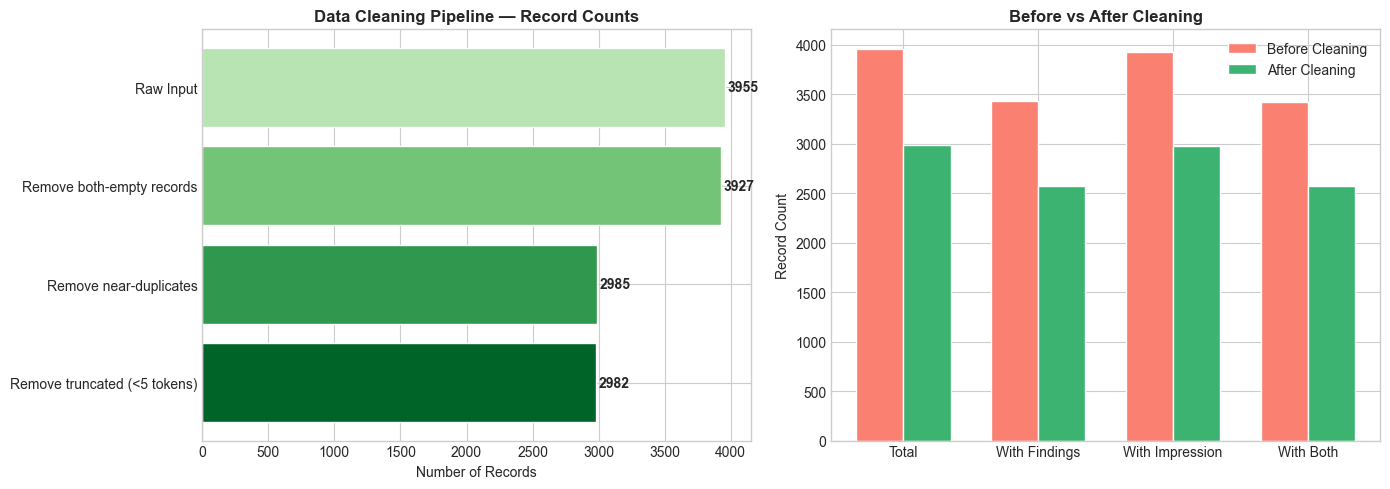

In [7]:
# Create cleaning summary visualization
print("=" * 60)
print("DATA CLEANING PIPELINE SUMMARY")
print("=" * 60)

cleaning_df = pd.DataFrame(cleaning_log, columns=['Step', 'Records_After', 'Removed', 'Reason'])
print(cleaning_df.to_string(index=False))

total_removed = initial_count - len(df_clean)
print(f"\n{'='*60}")
print(f"Total records removed: {total_removed} ({100*total_removed/initial_count:.1f}%)")
print(f"Final clean dataset: {len(df_clean)} records ({100*len(df_clean)/initial_count:.1f}% retained)")
print(f"{'='*60}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Funnel chart
ax = axes[0]
steps = cleaning_df['Step'].tolist()
counts = cleaning_df['Records_After'].tolist()
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(steps)))
bars = ax.barh(range(len(steps)), counts, color=colors, edgecolor='white')
ax.set_yticks(range(len(steps)))
ax.set_yticklabels(steps)
ax.set_xlabel('Number of Records')
ax.set_title('Data Cleaning Pipeline — Record Counts', fontweight='bold')
for i, (cnt, bar) in enumerate(zip(counts, bars)):
    ax.text(cnt + 20, i, f'{cnt}', va='center', fontweight='bold')
ax.invert_yaxis()

# Before/After comparison
ax = axes[1]
categories = ['Total', 'With Findings', 'With Impression', 'With Both']
before = [initial_count, 
          (df['findings'].fillna('')!='').sum(),
          (df['impression'].fillna('')!='').sum(),
          ((df['findings'].fillna('')!='') & (df['impression'].fillna('')!='')).sum()]
after = [len(df_clean),
         (df_clean['findings_clean']!='').sum(),
         (df_clean['impression_clean']!='').sum(),
         ((df_clean['findings_clean']!='') & (df_clean['impression_clean']!='')).sum()]

x = np.arange(len(categories))
width = 0.35
ax.bar(x - width/2, before, width, label='Before Cleaning', color='salmon', edgecolor='white')
ax.bar(x + width/2, after, width, label='After Cleaning', color='mediumseagreen', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Record Count')
ax.set_title('Before vs After Cleaning', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/07_cleaning_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# Save cleaned dataset
cols_to_save = ['uid', 'pmc_id', 'filename', 'findings_clean', 'impression_clean',
                'indication_clean', 'comparison', 'findings_expanded', 'impression_expanded',
                'mesh_major', 'mesh_minor', 'num_images', 'image_ids', 
                'findings', 'impression']  # Keep originals too

df_clean[cols_to_save].to_csv('../data/iu_cxr_cleaned.csv', index=False)
print(f"Cleaned dataset saved: ../data/iu_cxr_cleaned.csv")
print(f"Final shape: {df_clean[cols_to_save].shape}")
print(f"\nColumn summary:")
for col in cols_to_save:
    non_empty = (df_clean[col].fillna('') != '').sum()
    print(f"  {col:25s}: {non_empty} non-empty ({100*non_empty/len(df_clean):.1f}%)")


Cleaned dataset saved: ../data/iu_cxr_cleaned.csv
Final shape: (2982, 15)

Column summary:
  uid                      : 2982 non-empty (100.0%)
  pmc_id                   : 2982 non-empty (100.0%)
  filename                 : 2982 non-empty (100.0%)
  findings_clean           : 2573 non-empty (86.3%)
  impression_clean         : 2976 non-empty (99.8%)
  indication_clean         : 2946 non-empty (98.8%)
  comparison               : 2120 non-empty (71.1%)
  findings_expanded        : 2573 non-empty (86.3%)
  impression_expanded      : 2976 non-empty (99.8%)
  mesh_major               : 2982 non-empty (100.0%)
  mesh_minor               : 0 non-empty (0.0%)
  num_images               : 2982 non-empty (100.0%)
  image_ids                : 2891 non-empty (96.9%)
  findings                 : 2573 non-empty (86.3%)
  impression               : 2976 non-empty (99.8%)
